# Sanity check - outcomes pre and post stroke

Can outcomes get better?

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from dataclasses import dataclass


In [5]:
@dataclass(frozen=True)
class Paths:
    '''Singleton object for storing paths to data and database.'''

    data_read_path: str = '../../stroke_utilities/data/'
    output_folder = './stroke_utilities/output/'
    model_folder = './stroke_utilities/models'
    model_text = 'lgbm_decision_'
    notebook: str = '01_'

paths = Paths()

## Prepare data

In [6]:
train = pd.read_csv(f'{paths.data_read_path}/cohort_10000_train_outcomes.csv')
test = pd.read_csv(f'{paths.data_read_path}/cohort_10000_test_outcomes.csv')

In [7]:
train.columns

Index(['stroke_team_id', 'prior_disability', 'stroke_severity',
       'onset_to_thrombolysis', 'age', 'precise_onset_known',
       'any_afib_diagnosis', 'discharge_disability'],
      dtype='object')

Sanity check:

In [8]:
print(len(train))
print(len(train[train['discharge_disability'] >= 0]))
print(len(train[train['discharge_disability'] <= 6]))

85065
85065
85065


## Compare outcomes before and after stroke

In [10]:
mrs_scores_before = range(6)
mrs_scores_after = range(7)

df_score_options = pd.DataFrame()

for a in mrs_scores_before:
    for b in mrs_scores_after:
        mask = (
            (train['prior_disability'] == a) &
            (train['discharge_disability'] == b)
        )
        df_here = train[mask]
        n_here = len(df_here)
        df_score_options.loc[a, b] = n_here

df_score_options.index.name = 'prior_disability'

View the results. Columns are for each post-stroke disability score.

In [13]:
df_score_options

,0,1,2,3,4,5,6
prior_disability,,,,,,,
0,11352.0,12766.0,9067.0,5617.0,3423.0,1163.0,3641.0
1,619.0,4466.0,2821.0,1860.0,1241.0,515.0,1685.0
2,195.0,552.0,2734.0,1698.0,1036.0,469.0,1488.0
3,108.0,280.0,380.0,3483.0,1923.0,972.0,2499.0
4,28.0,79.0,99.0,236.0,2267.0,1090.0,1623.0
5,15.0,12.0,11.0,35.0,96.0,915.0,506.0


Check we didn't miss any patients:

In [15]:
df_score_options.sum().sum()

85065.0

We do see some patients with better outcomes after stroke than before.

In [18]:
for a in mrs_scores_before:
    n_a = df_score_options.loc[a].sum()
    n_improved = df_score_options.loc[a, range(a)].sum()
    perc_improved = 100.0 * n_improved / n_a
    print(a, n_a, n_improved, perc_improved)

0 47029.0 0.0 0.0
1 13207.0 619.0 4.686908457636102
2 8172.0 747.0 9.140969162995594
3 9645.0 768.0 7.962674961119752
4 5422.0 442.0 8.151973441534489
5 1590.0 169.0 10.628930817610064


Is there anything in common for these patients?

In [21]:
# Starting mRS
a = 5

df_a = train.loc[train['prior_disability'] == a]

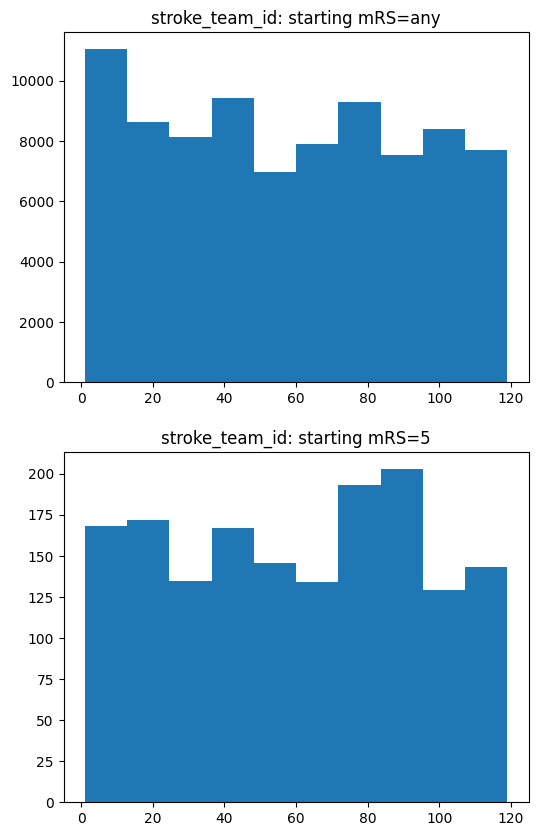

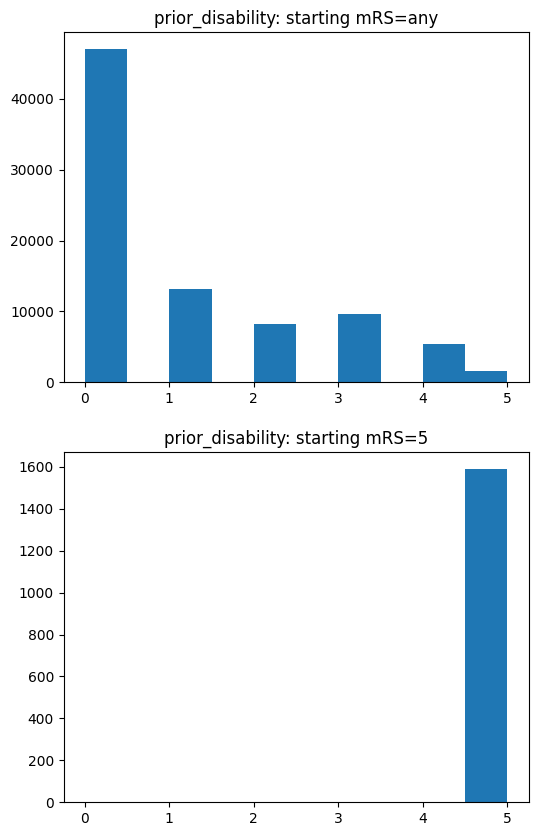

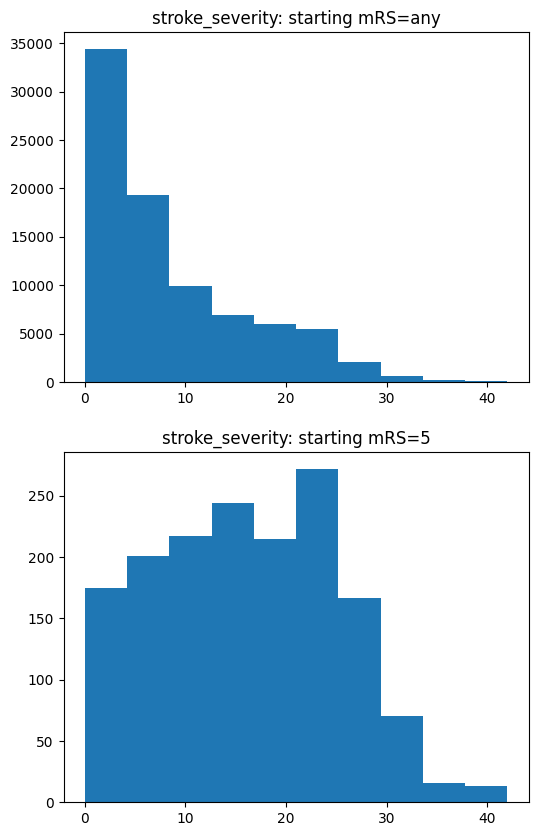

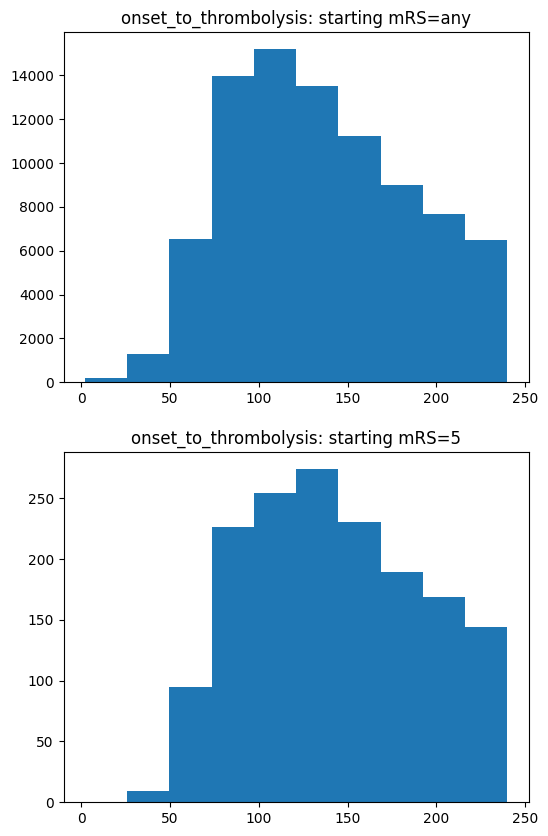

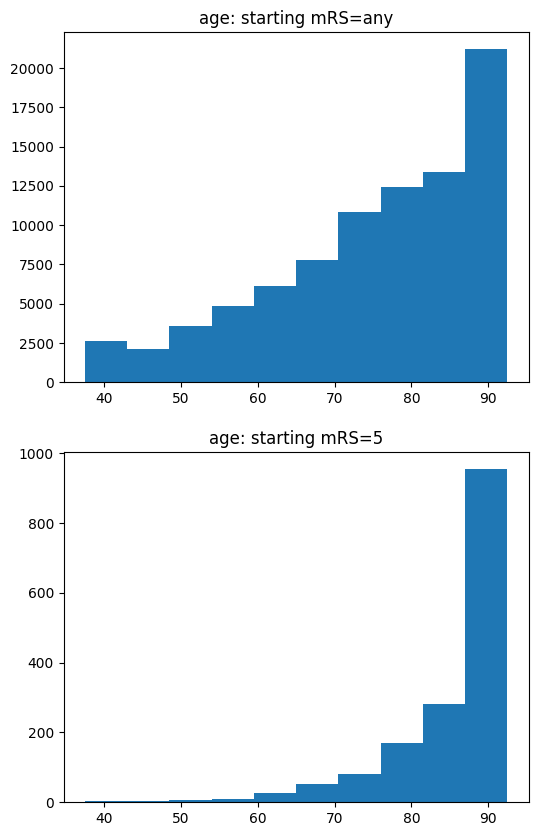

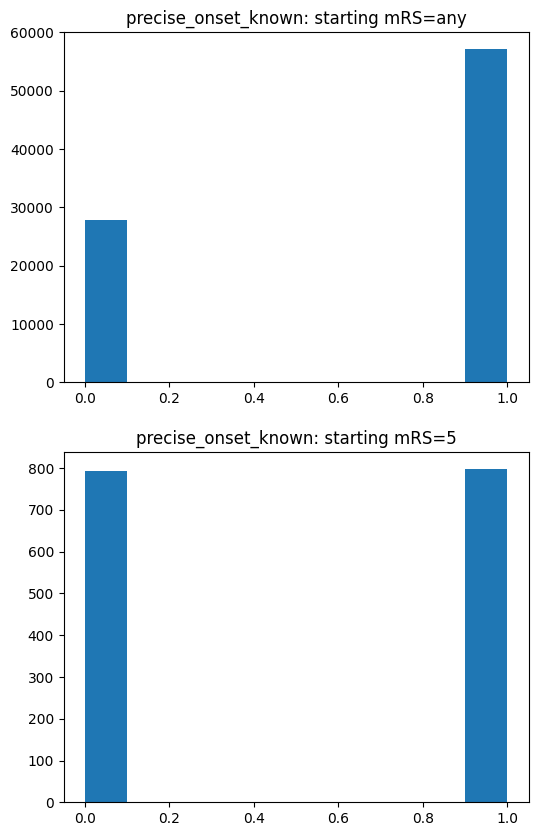

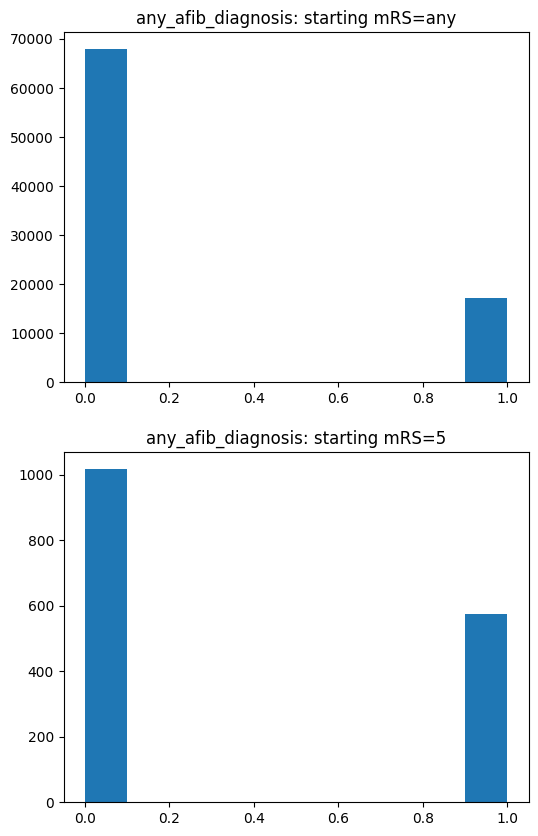

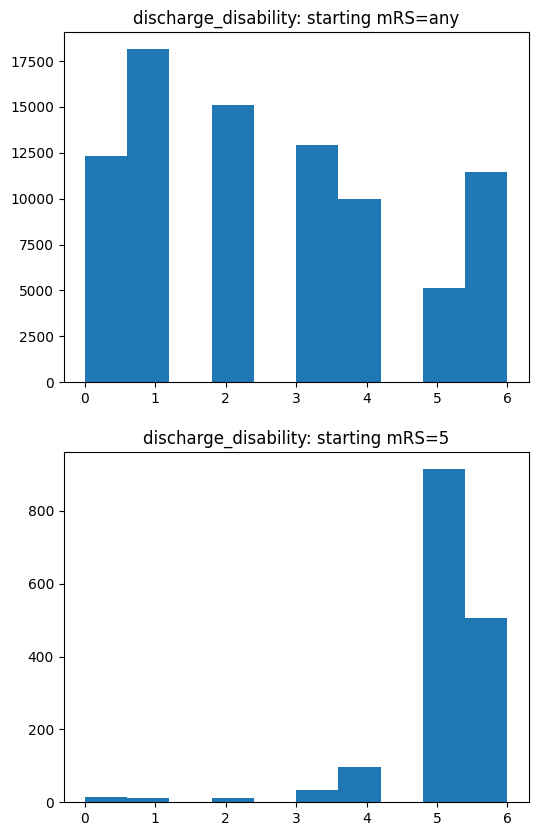

In [26]:
for col in df_a.columns:
    fig, axs = plt.subplots(2, 1, figsize=(6, 10))
    
    ax_all = axs[0]
    n, bins, patches = ax_all.hist(train[col])
    ax_all.set_title(f'{col}: starting mRS=any')
    
    ax_a = axs[1]
    ax_a.hist(df_a[col], bins=bins)
    ax_a.set_title(f'{col}: starting mRS={a}')
    
    plt.show()